In [8]:
from pathlib import Path
import pickle
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np


PAGE_WIDTH_CM=14

# 03_TRAIN_MODELS FIGURES

## Generalized performance
plot of $R^2$ for the individual labels (e.g., log U/Ks and log Ks/Ks), and the mean $R^2$ for the labels

In [2]:
# Define input file path
data_dir = Path.cwd().parent / "outputs" / "models" / "full-features"
filename="nested-cv-results-full-27dbc5a.pkl"
input_file_path = data_dir / filename


In [3]:
# read pickle file
with open(input_file_path, "rb") as f:  # "rb" means Read Binary
    results = pickle.load(f)

In [127]:
# get list of models
models=[m for m in list(results.keys()) if m[0]!="_"]
# get list of metrics
metrics=[m[5:] for m in list(results[list(results.keys())[0]].keys()) if m[:5]=='test_']
# get list of labels
labels=list(results['_meta']['label_names'])
label_scores=labels+['mean']

In [128]:
print(f'metrics: {metrics}')
print(f'label scores: {label_scores}')

metrics: ['r2', 'mse', 'rmse', 'mae']
label scores: ['u', 'kh', 'ks', 'mean']


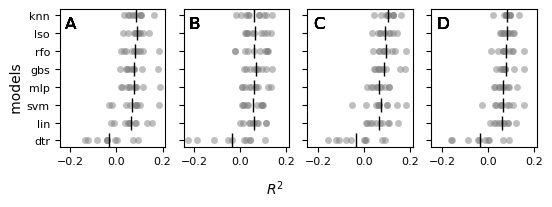

In [129]:
# figure settings and formats
fs_ytlab=8
fs_xtlab=8
fs_xlab=fs_xtlab+2
fs_annot=fs_xlab+2
fig_width_cm=PAGE_WIDTH_CM*14/14
fig_height_cm=5
ms_cv=5
ms_cv_mean=2*ms_cv
fig_dpi=600



#determine which metric to plot
metric='r2'
metric_label=r'$R^2$'

# determine order of models in y-axis, based on the mean label scores
mean_label_scores=[results[m][f'mean_test_{metric}'] for m in models]
sort_indices=np.argsort(mean_label_scores)
sorted_models=[models[i] for i in sort_indices]

# initialize figure
plt.close("all")
fig,axes=plt.subplots(nrows=1,ncols=len(label_scores),figsize=(fig_width_cm/2.54,fig_height_cm/2.54),sharey=True,sharex=True)
sp_label=['A','B','C','D']
# loop through sorted models
for sm, smodel in enumerate(sorted_models):
    # loop through label scores and figure axes
    for l,label in enumerate(label_scores):
        # get data to plot
        if 'mean' not in label:
            cv_scores=np.vstack(results[smodel][f'per_target_{metric}'])[:,l]
            mean_cv_score=np.mean(np.vstack(results[smodel][f'per_target_{metric}'])[:,l])
        else:
            cv_scores=results[smodel][f'test_{metric}']
            mean_cv_score=results[smodel][f'mean_test_{metric}']
        # plot data
        axes[l].plot(cv_scores,sm*np.ones(len(cv_scores)),'o',lw=0, mfc='0.5', alpha=0.5,mew=0,ms=ms_cv)
        axes[l].plot(mean_cv_score,sm,'k|',lw=2,ms=ms_cv_mean,mew=1)

        # set xticklabel fontsize
        axes[l].tick_params(labelsize=fs_xtlab)
        
        # add subplot label
        axes[l].text(0.05,0.95,sp_label[l],ha='left',va='top',fontsize=fs_annot,transform=axes[l].transAxes)

# rename y-axis tick labels
axes[0].set_yticks(np.arange(len(models)))
axes[0].set_yticklabels(sorted_models,fontsize=fs_ytlab)

# add x-axis label
fig.supxlabel(metric_label,fontsize=fs_xlab)
fig.supylabel('      models',fontsize=fs_xlab)
fig.tight_layout(pad=0.5)
fig.savefig(f'{filename.split(".")[0]}-generalized-{metric}.jpg',dpi=fig_dpi)
fig.savefig(f'{filename.split(".")[0]}-generalized-{metric}.svg')
# plt.close("all")


## Performance on unseen test set

In [130]:
# define input file path for features and labels
data_dir2 = Path.cwd().parent / "outputs" / "features"
filename2="features-all.pkl"
input_file_path2 = data_dir2 / filename2

# read pickle file
with open(input_file_path2, "rb") as f:  # "rb" means Read Binary
    features_df = pickle.load(f)


In [131]:
test_idx=results['_meta']['test_idx']
features_df.loc[test_idx]
features=results['_meta']['feature_names']
labels=results['_meta']['label_names']

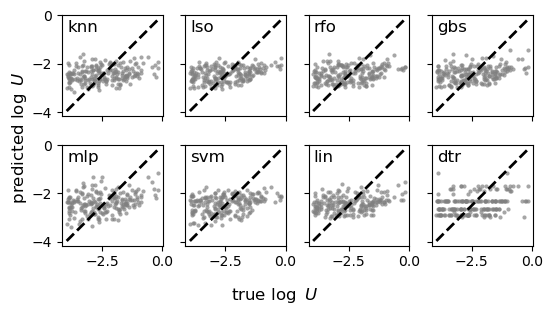

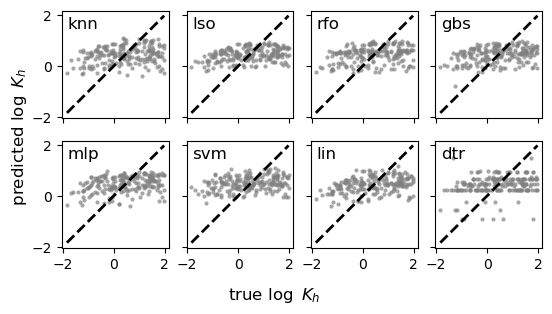

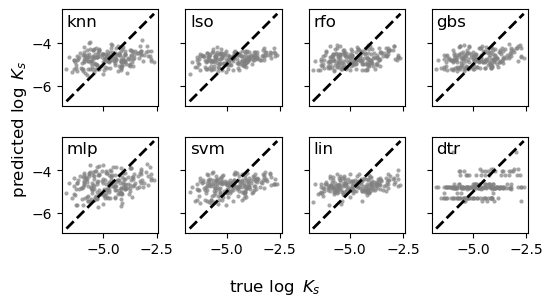

In [132]:
# figure settings and formats
fs_ytlab=8
fs_xtlab=8
fs_xlab=fs_xtlab+2
fs_annot=fs_xlab+2
fig_width_cm=PAGE_WIDTH_CM*14/14
fig_height_cm=8
ms=3
malpha=0.7
fig_dpi=600



plt.close("all")

fig1,axes1=plt.subplots(nrows=2,ncols=4,figsize=(fig_width_cm/2.54,fig_height_cm/2.54),sharex=True,sharey=True)
fig2,axes2=plt.subplots(nrows=2,ncols=4,figsize=(fig_width_cm/2.54,fig_height_cm/2.54),sharex=True,sharey=True)
fig3,axes3=plt.subplots(nrows=2,ncols=4,figsize=(fig_width_cm/2.54,fig_height_cm/2.54),sharex=True,sharey=True)

axes1=axes1.flatten()
axes2=axes2.flatten()
axes3=axes3.flatten()

for m,model in enumerate(sorted_models[::-1]):
    rgr=results[model]['final_model']['regressor']
    ypred=rgr.predict(features_df.loc[test_idx,features])
    ytrue=features_df.loc[test_idx,labels]
    axes1[m].plot(np.log10(ytrue.loc[:,labels[0]]),ypred[:,0],marker='o',mfc='0.5',mew=0,lw=0,ms=ms,alpha=malpha)
    axes1[m].plot([np.min(np.log10(ytrue.loc[:,labels[0]])),np.max(np.log10(ytrue.loc[:,labels[0]]))],
                  [np.min(np.log10(ytrue.loc[:,labels[0]])),np.max(np.log10(ytrue.loc[:,labels[0]]))],
                  ls='--',c='k',lw=2)
    axes1[m].text(0.05,0.95,model,ha='left',va='top',fontsize=fs_annot,transform=axes1[m].transAxes)

    axes2[m].plot(np.log10(ytrue.loc[:,labels[1]]),ypred[:,1],marker='o',mfc='0.5',mew=0,lw=0,ms=ms,alpha=malpha)
    axes2[m].plot([np.min(np.log10(ytrue.loc[:,labels[1]])),np.max(np.log10(ytrue.loc[:,labels[1]]))],
                  [np.min(np.log10(ytrue.loc[:,labels[1]])),np.max(np.log10(ytrue.loc[:,labels[1]]))],
                  ls='--',c='k',lw=2)
    axes2[m].text(0.05,0.95,model,ha='left',va='top',fontsize=fs_annot,transform=axes2[m].transAxes)


    axes3[m].plot(np.log10(ytrue.loc[:,labels[2]]),ypred[:,2],marker='o',mfc='0.5',mew=0,lw=0,ms=ms,alpha=malpha)
    axes3[m].plot([np.min(np.log10(ytrue.loc[:,labels[2]])),np.max(np.log10(ytrue.loc[:,labels[2]]))],
                  [np.min(np.log10(ytrue.loc[:,labels[2]])),np.max(np.log10(ytrue.loc[:,labels[2]]))],
                  ls='--',c='k',lw=2)
    axes3[m].text(0.05,0.95,model,ha='left',va='top',fontsize=fs_annot,transform=axes3[m].transAxes)
    
    axes1[m].axis('scaled')
    axes2[m].axis('scaled')
    axes3[m].axis('scaled')
fig1.supxlabel(fr'true $\log\ U$')
fig2.supxlabel(fr'true $\log\ K_h$')
fig3.supxlabel(fr'true $\log\ K_s$')
fig1.supylabel(fr'     predicted $\log\ U$')
fig2.supylabel(fr'     predicted $\log\ K_h$')
fig3.supylabel(fr'     predicted $\log\ K_s$')

fig2.tight_layout(pad=0.5)
fig1.tight_layout(pad=0.5)
fig3.tight_layout(pad=0.5)

filename="nested-cv-results-full-27dbc5a.pkl"
fig1.savefig(f'{filename.split(".")[0]}-unseen-test-set-{labels[0]}.jpg',dpi=fig_dpi)
fig1.savefig(f'{filename.split(".")[0]}-unseen-test-set-{labels[0]}.svg')
fig2.savefig(f'{filename.split(".")[0]}-unseen-test-set-{labels[1]}.jpg',dpi=fig_dpi)
fig2.savefig(f'{filename.split(".")[0]}-unseen-test-set-{labels[1]}.svg')
fig3.savefig(f'{filename.split(".")[0]}-unseen-test-set-{labels[2]}.jpg',dpi=fig_dpi)
fig3.savefig(f'{filename.split(".")[0]}-unseen-test-set-{labels[2]}.svg')
    

## Combined Plots
A: Generalized performance ($R^2$) of models trained to estimate the individual LEM parameters, with $\texttt{knn}$ as the best model. Black vertical bars show the means of the individual cross validation fold scores (gray dots). $R^2$ for all models are less than 0.2.

B to D: Performance of the best model for estimating $\log\ U$, $\log\ K_h$, and $\log\ K_s$ for an unseen test set. Dashed line represents the 1:1 line, and shows that 

E: Generalized performance ($R^2$) of models trained to estimate the LEM parameter ratios, with $\texttt{mlp}$ as the best model. $R^2$ for all models are more than 0.9.

F to G: Performance of the best model for estimating $\log\ U/K_s$ and $\log\ K_h/K_s$$ for an unseen test set. 

In [123]:
# read input file for model results
def read_model_results(data_dir,filename):
    input_file_path = data_dir / filename
    with open(input_file_path, "rb") as f:  # "rb" means Read Binary
        results = pickle.load(f)
    
    # get list of models
    models=[m for m in list(results.keys()) if m[0]!="_"]
    # get list of metrics
    metrics=[m[5:] for m in list(results[list(results.keys())[0]].keys()) if m[:5]=='test_']
    # get list of labels
    labels=list(results['_meta']['label_names'])
    # get list of features
    features=results['_meta']['feature_names']
    # get test set indices
    test_idx=results['_meta']['test_idx']

    return results, models, metrics, labels, features, test_idx

# read input file for features and labels
data_dir2 = Path.cwd().parent / "outputs" / "features"
filename2="features-all.pkl"
input_file_path2 = data_dir2 / filename2
with open(input_file_path2, "rb") as f:  # "rb" means Read Binary
    features_df = pickle.load(f)



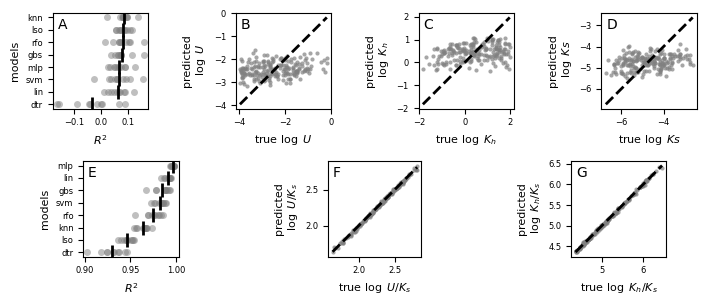

In [124]:
# figure settings and formats
PAGE_WIDTH_CM=19

fs_ytlab=6
fs_xtlab=6
fs_xlab=fs_xtlab+2
fs_annot=fs_xlab+2
fig_width_cm=PAGE_WIDTH_CM*19/19
fig_height_cm=8
ms_cv=5
ms_cv_mean=2*ms_cv
ms=3
malpha=0.7
fig_dpi=600



# SETUP FIGURE AND SUBPLOTS
fig = plt.figure(figsize=(fig_width_cm/2.54, fig_height_cm/2.54))
# GridSpec: 2 rows, 12 columns (LCM of 3 and 4)
gs = gridspec.GridSpec(2, 12, figure=fig)
# set top row to have 4 subplots
axt = [fig.add_subplot(gs[0, i*3:(i+1)*3]) for i in range(4)]
# set bottom row to have 3 subplots
axb = [fig.add_subplot(gs[1, i*4:(i+1)*4]) for i in range(3)]


# TOP ROW PLOTS ──────────────────────────
# read input file for model results (u, kh, and ks as labels)
data_dir = Path.cwd().parent / "outputs" / "models" / "full-features"
filename="nested-cv-results-full-27dbc5a.pkl"
results, models, metrics, labels, features, test_idx = read_model_results(data_dir,filename)

#determine which metric to plot
metric='r2'
metric_label=r'$R^2$'

# determine order of models in y-axis, based on the mean label scores
mean_label_scores=[results[m][f'mean_test_{metric}'] for m in models]
sort_indices=np.argsort(mean_label_scores)
sorted_models=[models[i] for i in sort_indices]

sp_labels=['A','B','C','D']
# loop through sorted models
for sm, smodel in enumerate(sorted_models):
    # get data to plot
    cv_scores=results[smodel][f'test_{metric}']
    mean_cv_score=results[smodel][f'mean_test_{metric}']
    # plot data
    axt[0].plot(cv_scores,sm*np.ones(len(cv_scores)),'o',lw=0, mfc='0.5', alpha=0.5,mew=0,ms=ms_cv)
    axt[0].plot(mean_cv_score,sm,'k|',lw=2,ms=ms_cv_mean,mew=2)
    # add subplot label
    if sm==0:
        axt[0].text(0.05,0.95,sp_labels[0],ha='left',va='top',fontsize=fs_annot,transform=axt[0].transAxes)
axt[0].set_box_aspect(1)

# rename y-axis tick labels, add x-axis label
axt[0].set_yticks(np.arange(len(models)))
axt[0].set_yticklabels(sorted_models,fontsize=fs_ytlab)
axt[0].set_xlabel(metric_label,fontsize=fs_xlab)
axt[0].set_ylabel('models',fontsize=fs_xlab)
axt[0].tick_params(axis='x',labelsize=fs_xtlab)



ax_labels=[r'$\log\ U$',r'$\log\ K_h$',r'$\log\ Ks$']
for m,model in enumerate(sorted_models[::-1]):
    rgr=results[model]['final_model']['regressor']
    ypred=rgr.predict(features_df.loc[test_idx,features])
    ytrue=features_df.loc[test_idx,labels]
    for sp in range(1,len(axt)):
        axt[sp].plot(np.log10(ytrue.loc[:,labels[sp-1]]),ypred[:,sp-1],marker='o',mfc='0.5',mew=0,lw=0,ms=ms,alpha=malpha)
        
        axt[sp].plot([np.min(np.log10(ytrue.loc[:,labels[sp-1]])),np.max(np.log10(ytrue.loc[:,labels[sp-1]]))],
                      [np.min(np.log10(ytrue.loc[:,labels[sp-1]])),np.max(np.log10(ytrue.loc[:,labels[sp-1]]))],
                      ls='--',c='k',lw=2)
        
        axt[sp].text(0.05,0.95,sp_labels[sp],ha='left',va='top',fontsize=fs_annot,transform=axt[sp].transAxes)
        axt[sp].set_xlabel('true '+ax_labels[sp-1],fontsize=fs_xlab)
        axt[sp].set_ylabel('predicted\n '+ax_labels[sp-1],fontsize=fs_xlab)
        axt[sp].axis('scaled')
        axt[sp].set_anchor('C')
        axt[sp].tick_params(labelsize=fs_xtlab)
        
    break




# BOTTOM ROW PLOTS ──────────────────────────
# read input file for model results (u/ks and kh/ks as labels)
data_dir = Path.cwd().parent / "outputs" / "models" / "full-features"
filename="nested-cv-results-full-886a995.pkl"
results, models, metrics, labels, features, test_idx = read_model_results(data_dir,filename)

#determine which metric to plot
metric='r2'
metric_label=r'$R^2$'

# determine order of models in y-axis, based on the mean label scores
mean_label_scores=[results[m][f'mean_test_{metric}'] for m in models]
sort_indices=np.argsort(mean_label_scores)
sorted_models=[models[i] for i in sort_indices]

sp_labels=['E','F','G']

# loop through sorted models
for sm, smodel in enumerate(sorted_models):
    # get data to plot
    cv_scores=results[smodel][f'test_{metric}']
    mean_cv_score=results[smodel][f'mean_test_{metric}']
    # plot data
    axb[0].plot(cv_scores,sm*np.ones(len(cv_scores)),'o',lw=0, mfc='0.5', alpha=0.5,mew=0,ms=ms_cv)
    axb[0].plot(mean_cv_score,sm,'k|',lw=2,ms=ms_cv_mean,mew=2)
    # add subplot label
    if sm==0:
        axb[0].text(0.05,0.95,sp_labels[0],ha='left',va='top',fontsize=fs_annot,transform=axb[0].transAxes)
axb[0].set_box_aspect(1)

# rename y-axis tick labels, add x-axis label
axb[0].set_yticks(np.arange(len(models)))
axb[0].set_yticklabels(sorted_models,fontsize=fs_ytlab)
axb[0].set_xlabel(metric_label,fontsize=fs_xlab)
axb[0].set_ylabel('models',fontsize=fs_xlab)
axb[0].tick_params(axis='x',labelsize=fs_xtlab)

# axb[0].set_anchor('E')
# set xticklabel fontsize
    
ax_labels=[r'$\log\ U/K_s$',r'$\log\ K_h/K_s$']
for m,model in enumerate(sorted_models[::-1]):
    rgr=results[model]['final_model']['regressor']
    ypred=rgr.predict(features_df.loc[test_idx,features])
    ytrue=features_df.loc[test_idx,labels]
    for sp in range(1,len(axb)):
        axb[sp].plot(np.log10(ytrue.loc[:,labels[sp-1]]),ypred[:,sp-1],marker='o',mfc='0.5',mew=0,lw=0,ms=ms,alpha=malpha)
        
        axb[sp].plot([np.min(np.log10(ytrue.loc[:,labels[sp-1]])),np.max(np.log10(ytrue.loc[:,labels[sp-1]]))],
                      [np.min(np.log10(ytrue.loc[:,labels[sp-1]])),np.max(np.log10(ytrue.loc[:,labels[sp-1]]))],
                      ls='--',c='k',lw=2)
        
        axb[sp].text(0.05,0.95,sp_labels[sp],ha='left',va='top',fontsize=fs_annot,transform=axb[sp].transAxes)
        axb[sp].set_xlabel('true '+ax_labels[sp-1],fontsize=fs_xlab)
        axb[sp].set_ylabel('predicted\n '+ax_labels[sp-1],fontsize=fs_xlab)
        axb[sp].axis('scaled')
        # if sp==1:
            # axb[sp].set_anchor('C')
        # if sp==2:
            # axb[sp].set_anchor('W')
        axb[sp].tick_params(labelsize=fs_xtlab)
    break

fig.tight_layout(h_pad=1)

fig.savefig(f'nested-cv-results-all-labels-generalized-and-unseen-test-set.jpg',dpi=fig_dpi)
fig.savefig(f'nested-cv-results-all-labels-generalized-and-unseen-test-set.svg')

# 04_FEATURE_IMPORTANCE FIGURES